## Preprocessing

In [1]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


df = pd.read_csv('BMW sales data (2010-2024) (1).csv')
# df.head()
# df.shape ==> # (50000, 11)
df.info()
# df.columns  #  ==>best information with table
df.describe()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Model                 50000 non-null  object 
 1   Year                  50000 non-null  int64  
 2   Region                50000 non-null  object 
 3   Color                 50000 non-null  object 
 4   Fuel_Type             50000 non-null  object 
 5   Transmission          50000 non-null  object 
 6   Engine_Size_L         50000 non-null  float64
 7   Mileage_KM            50000 non-null  int64  
 8   Price_USD             50000 non-null  int64  
 9   Sales_Volume          50000 non-null  int64  
 10  Sales_Classification  50000 non-null  object 
dtypes: float64(1), int64(4), object(6)
memory usage: 4.2+ MB


,Year,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,2017.015700,3.247180,100307.203140,75034.600900,5067.514680
std,4.324459,1.009078,57941.509344,25998.248882,2856.767125
min,2010.000000,1.500000,3.000000,30000.000000,100.000000
25%,2013.000000,2.400000,50178.000000,52434.750000,2588.000000
50%,2017.000000,3.200000,100388.500000,75011.500000,5087.000000
75%,2021.000000,4.100000,150630.250000,97628.250000,7537.250000
max,2024.000000,5.000000,199996.000000,119998.000000,9999.000000


In [2]:
a=df['Region'].unique()
b=df['Region'].count()

print(a,'\n\n',b)
print(len(a))


['Asia' 'North America' 'Middle East' 'South America' 'Europe' 'Africa'] 

 50000
6


In [3]:
df

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification
0,5 Series,2016,Asia,Red,Petrol,Manual,3.5,151748,98740,8300,High
1,i8,2013,North America,Red,Hybrid,Automatic,1.6,121671,79219,3428,Low
2,5 Series,2022,North America,Blue,Petrol,Automatic,4.5,10991,113265,6994,Low
3,X3,2024,Middle East,Blue,Petrol,Automatic,1.7,27255,60971,4047,Low
4,7 Series,2020,South America,Black,Diesel,Manual,2.1,122131,49898,3080,Low
...,...,...,...,...,...,...,...,...,...,...,...
49995,i3,2014,Asia,Red,Hybrid,Manual,4.6,151030,42932,8182,High
49996,i3,2023,Middle East,Silver,Electric,Manual,4.2,147396,48714,9816,High
49997,5 Series,2010,Middle East,Red,Petrol,Automatic,4.5,174939,46126,8280,High
49998,i3,2020,Asia,White,Electric,Automatic,3.8,3379,58566,9486,High


<Axes: xlabel='Year'>

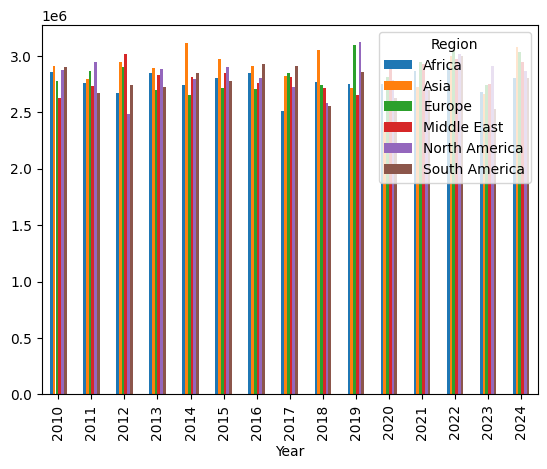

In [4]:
df.groupby(['Year', 'Region'])['Sales_Volume'].sum().unstack().plot(kind='bar')


In [5]:
# tiran & a test
Train_data_model,Test_data_model = train_test_split(df,test_size=0.2,random_state=42)


##  Sales Analysis by Country, Color, Model, and Fuel Type

This section explores which combinations of **Country**, **Color**, **Model**, and **Fuel Type** have the highest and lowest total sales.  
By grouping and summarizing the data across these features, we can quickly identify the most popular configurations and those with low performance — offering insights into customer preferences and potential market opportunities.


In [6]:
Top_sales_country = df.groupby('Region')['Sales_Volume'].sum().sort_values(ascending=False) # =>Asia
Top_sales_Color  = df.groupby('Color')['Sales_Volume'].sum().sort_values(ascending=False)  # => Red
Top_sales_Model  = df.groupby('Model')['Sales_Volume'].sum().sort_values(ascending=False) # => 7 
Top_sales_Fuel_Type  = df.groupby('Fuel_Type')['Sales_Volume'].sum().sort_values(ascending=False) # => Hybrid / Petrol / Electric / Diesel

result=f'Top_sales_country is: \n {Top_sales_country} \n\n Top_sales_Color : {Top_sales_Color} \n\n Top_sales_Model : {Top_sales_Model} \n\n Top_sales_Fuel_type : {Top_sales_Fuel_Type} '

print(result)


Top_sales_country is: 
 Region
Asia             42974277
Europe           42555138
North America    42402629
Middle East      42326620
Africa           41565252
South America    41551818
Name: Sales_Volume, dtype: int64 

 Top_sales_Color : Color
Red       42750183
Silver    42674022
White     42272954
Grey      41995141
Blue      41972741
Black     41710693
Name: Sales_Volume, dtype: int64 

 Top_sales_Model : Model
7 Series    23786466
i8          23423891
X1          23406060
3 Series    23281303
i3          23133849
5 Series    23097519
M5          22779688
X3          22745529
X5          22709749
X6          22661986
M3          22349694
Name: Sales_Volume, dtype: int64 

 Top_sales_Fuel_type : Fuel_Type
Hybrid      64532097
Petrol      63324154
Electric    63157665
Diesel      62361818
Name: Sales_Volume, dtype: int64 


### Analysis of the Most Expensive BMW Configurations

In this section, we analyze which combinations of features — including **Model**, **Year**, **Color**, **Fuel Type**, **Transmission**, and **Engine Size (L)** — are associated with the highest prices in USD.  
By aggregating and comparing average prices across these dimensions, we can identify the most premium configurations and understand how different factors such as engine size, transmission type, or color influence the overall market value of BMW vehicles.  
This analysis helps reveal trends in pricing and highlights which characteristics are most strongly linked to high-end models.


In [7]:
High_Price = df.groupby(['Model','Year','Color','Fuel_Type','Transmission','Engine_Size_L','Price_USD'])['Sales_Volume'].sum().reset_index()

Top_High_Price = High_Price.loc[
    High_Price.groupby('Model')['Sales_Volume'].idxmax()
].sort_values(by='Sales_Volume',ascending=False)

print(Top_High_Price)

          Model  Year   Color Fuel_Type Transmission  Engine_Size_L  \
2168   3 Series  2017   Black  Electric    Automatic            2.7   
9153   5 Series  2024   White  Electric       Manual            2.5   
13746  7 Series  2024  Silver    Diesel    Automatic            3.7   
17591        M3  2022     Red    Petrol       Manual            4.8   
27824        X3  2011  Silver  Electric       Manual            2.0   
21052        M5  2019    Grey    Petrol       Manual            3.8   
23404        X1  2012    Blue    Diesel       Manual            2.1   
32759        X5  2013    Blue    Diesel       Manual            2.4   
45590        i8  2010     Red    Hybrid    Automatic            4.3   
36513        X6  2010  Silver  Electric       Manual            4.7   
43417        i3  2018     Red    Diesel       Manual            1.8   

       Price_USD  Sales_Volume  
2168       64641          9999  
9153       88572          9999  
13746      71167          9999  
17591      3812

### Sales Analysis by Fuel Type

This section examines how total sales vary across different **fuel types**, providing insights into customer preferences and demand trends.


In [8]:
sales_by_country_type = df.groupby(['Region', 'Fuel_Type'])['Sales_Volume'].sum().reset_index()

top_model_per_country = sales_by_country_type.loc[
    sales_by_country_type.groupby('Region')['Sales_Volume'].idxmax()
].sort_values(by='Sales_Volume',ascending=False)


print(top_model_per_country)


           Region Fuel_Type  Sales_Volume
6            Asia    Hybrid      11422396
17  North America  Electric      10861198
10         Europe    Hybrid      10825662
15    Middle East    Petrol      10812148
3          Africa    Petrol      10538463
20  South America    Diesel      10500121


# Converting Categorical Data to Binary
### with One_Hot_Encoding & Label_Encoding


In [9]:
# create a copy for data frem
binData=df.copy()

In [10]:
binData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Model                 50000 non-null  object 
 1   Year                  50000 non-null  int64  
 2   Region                50000 non-null  object 
 3   Color                 50000 non-null  object 
 4   Fuel_Type             50000 non-null  object 
 5   Transmission          50000 non-null  object 
 6   Engine_Size_L         50000 non-null  float64
 7   Mileage_KM            50000 non-null  int64  
 8   Price_USD             50000 non-null  int64  
 9   Sales_Volume          50000 non-null  int64  
 10  Sales_Classification  50000 non-null  object 
dtypes: float64(1), int64(4), object(6)
memory usage: 4.2+ MB


In [11]:
# one hot encoding
from sklearn.preprocessing import OneHotEncoder
# obj
encoder_1hot = OneHotEncoder(sparse_output=False , drop=None)

#Columns that should be One_Hot
Categorical_list_1hot=['Region','Color','Fuel_Type']

Data_1hot = encoder_1hot.fit_transform(binData[Categorical_list_1hot])
Data_df = pd.DataFrame(Data_1hot,columns=encoder_1hot.get_feature_names_out(Categorical_list_1hot))


final = pd.concat([binData.drop(columns=Categorical_list_1hot),Data_df],axis=1)
final.head()

,Model,Year,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification,Region_Africa,Region_Asia,...,Color_Black,Color_Blue,Color_Grey,Color_Red,Color_Silver,Color_White,Fuel_Type_Diesel,Fuel_Type_Electric,Fuel_Type_Hybrid,Fuel_Type_Petrol
0,5 Series,2016,Manual,3.5,151748,98740,8300,High,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,i8,2013,Automatic,1.6,121671,79219,3428,Low,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,5 Series,2022,Automatic,4.5,10991,113265,6994,Low,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,X3,2024,Automatic,1.7,27255,60971,4047,Low,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,7 Series,2020,Manual,2.1,122131,49898,3080,Low,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [15]:
# lable encoding
from sklearn.preprocessing import LabelEncoder

#Columns that should be Label encoder
Categorical_list_encoded =binData[['Transmission','Sales_Classification']]

# Dictionary to store encoded columns
data_cat_encoded={}

for i in Categorical_list_encoded: 
    objLabel = LabelEncoder()
    data_cat_encoded[i + '_LE'] = objLabel.fit_transform(binData[i])

# Convert encoded values to DataFrame
data_cat_encoded = pd.DataFrame(data_cat_encoded)

# Drop original columns and append encoded columns
result = pd.concat([binData.drop(columns=Categorical_list_encoded),data_cat_encoded],axis=1)

result.head(40)

,Model,Year,Region,Color,Fuel_Type,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Transmission_LE,Sales_Classification_LE
0,5 Series,2016,Asia,Red,Petrol,3.5,151748,98740,8300,1,0
1,i8,2013,North America,Red,Hybrid,1.6,121671,79219,3428,0,1
2,5 Series,2022,North America,Blue,Petrol,4.5,10991,113265,6994,0,1
3,X3,2024,Middle East,Blue,Petrol,1.7,27255,60971,4047,0,1
4,7 Series,2020,South America,Black,Diesel,2.1,122131,49898,3080,1,1
5,5 Series,2017,Middle East,Silver,Diesel,1.9,171362,42926,1232,1,1
6,i8,2022,Europe,White,Diesel,1.8,196741,55064,7949,1,0
7,M5,2014,Asia,Black,Diesel,1.6,121156,102778,632,0,1
8,X3,2016,South America,White,Diesel,1.7,48073,116482,8944,0,0
9,i8,2019,Europe,White,Electric,3.0,35700,96257,4411,1,1
